Project Title
Customer Churn Analysis -
IBM Telco Customer Churn

Project: IBM Telco Customer Churn

1. Project Title

Customer Churn Analysis Using Python



2. Business Problem

The telecom company is experiencing customer churn and wants to identify the factors contributing to it. The objective is to analyze customer data and provide insights that can help reduce churn and improve customer retention.

3. Business Objectives

1.Understand customer behavior.

2.Identify the main reasons for customer churn.

3.Analyze how customer demographics, services, contracts

4.billing affect churn.

5.Provide recommendations to reduce churn.



Data Exploration

The following table describes the features available in the IBM Telco Customer Churn dataset.

Customer ID: Unique identifier assigned to each customer.

Gender: Gender of the customer (Male/Female).

Senior Citizen: Indicates whether the customer is a senior citizen (1 = Yes, 0 = No).

Partner: Indicates whether the customer has a partner (Yes/No).

Dependents: Indicates whether the customer has dependents (Yes/No).

Tenure: Number of months the customer has stayed with the company.

Phone Service: Indicates whether the customer has phone service (Yes/No).

Multiple Lines: Indicates whether the customer has multiple phone lines.

Internet Service: Type of internet service (DSL, Fiber Optic, No).

Online Security: Whether the customer has online security service.

Online Backup: Whether the customer has online backup service.

Device Protection: Whether the customer has device protection service.

Tech Support: Whether the customer has technical support service.

Streaming TV: Whether the customer subscribes to streaming TV.

Streaming Movies: Whether the customer subscribes to streaming movie services.

Contract: Customer contract type (Month-to-Month, One Year, Two Year).

Paperless Billing: Indicates whether the customer uses paperless billing.

Payment Method: Payment method used by the customer.

Monthly Charges: Monthly amount charged to the customer.

Total Charges: Total amount charged to the customer since joining.

Churn: Indicates whether the customer left the company (Yes/No).


Business Questions

1.What percentage of customers have churned?

2.Does gender affect churn?

3.Does senior citizen status affect churn?

4.Which contract type has the highest churn?

5.Which payment method has the highest churn?

6.Does internet service influence churn?

7.Are customers with shorter tenure more likely to churn?

8.Do higher monthly charges increase churn?

9.Which services help retain customers?

10.Which customer segment has the highest churn risk?

In [7]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Loading the data set
df=pd.read_csv("Telco_customer_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
#Display first 5 rows
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
#Shape of the data
df.shape

(7043, 21)

In [11]:
#info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
#columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
#Data types
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [14]:
#summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
#unique values
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


Data cleaning




In [16]:
#checking missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
#checking blank spaces
(df==" ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
#replace blank spaces with nan
df['TotalCharges']=df['TotalCharges'].replace(" ",np.nan)

In [19]:
#convert Total charges into numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [20]:
#filling blank rows
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [21]:
#check duplicate values
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis

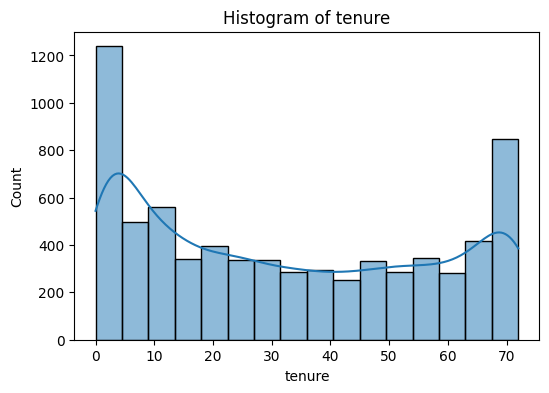

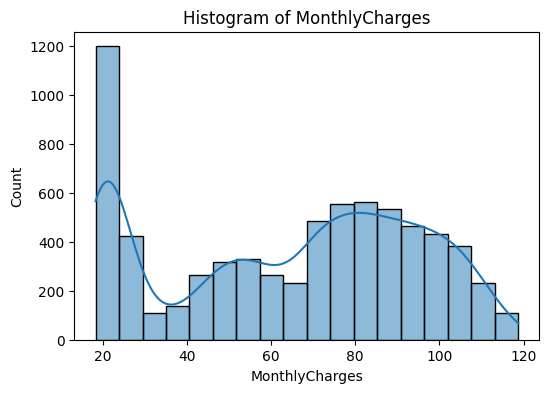

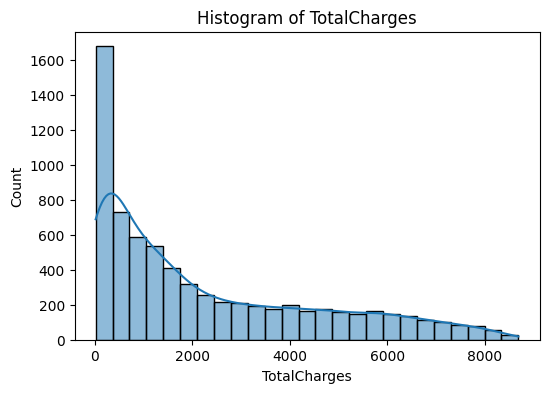

In [22]:
# Histogram for Numerical Columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

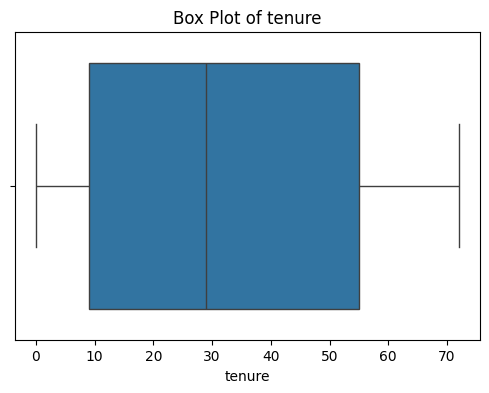

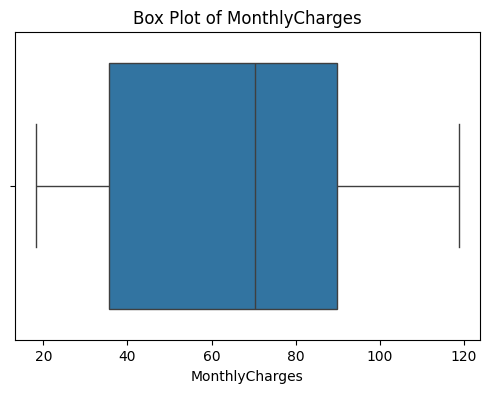

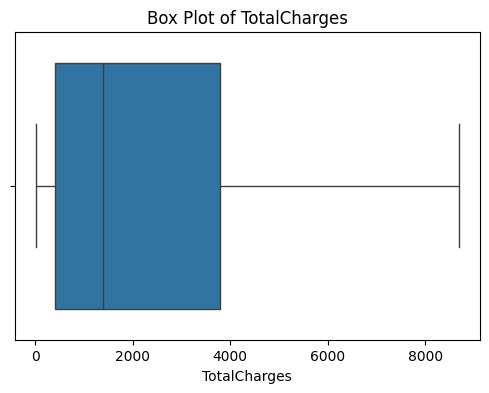

In [23]:
# Box Plot for Numerical Columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

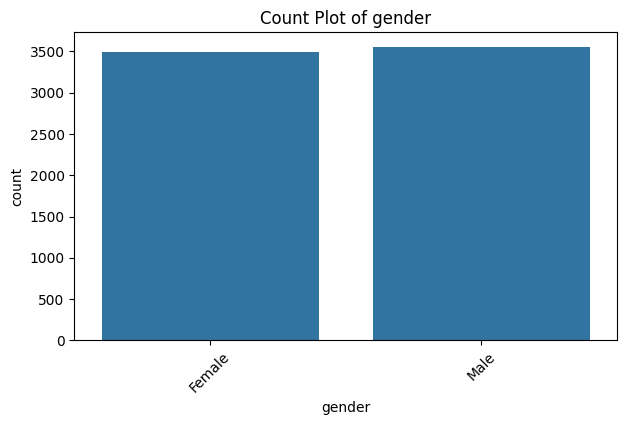

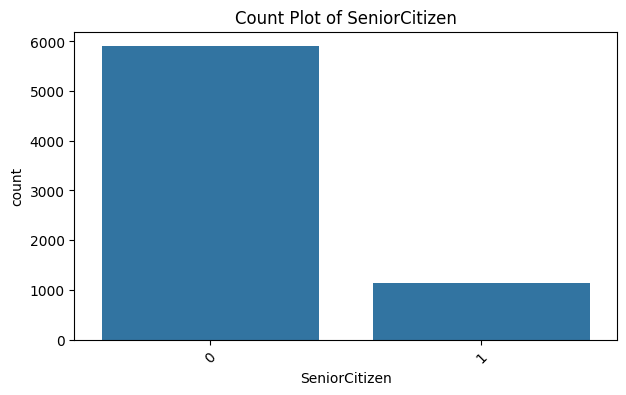

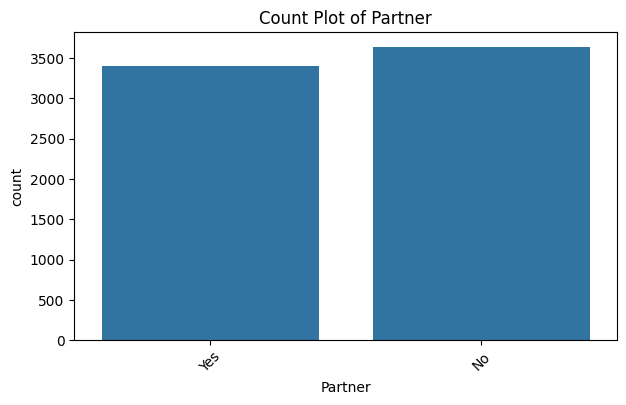

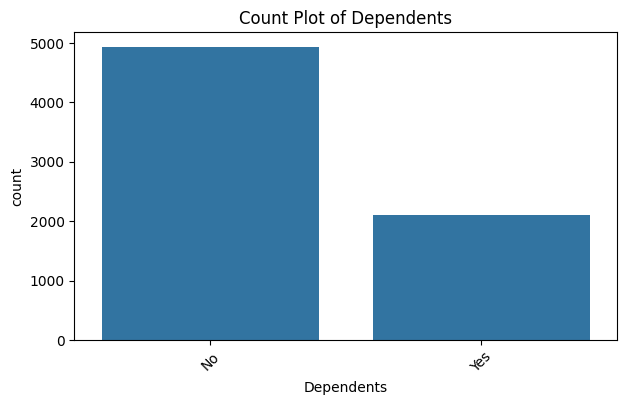

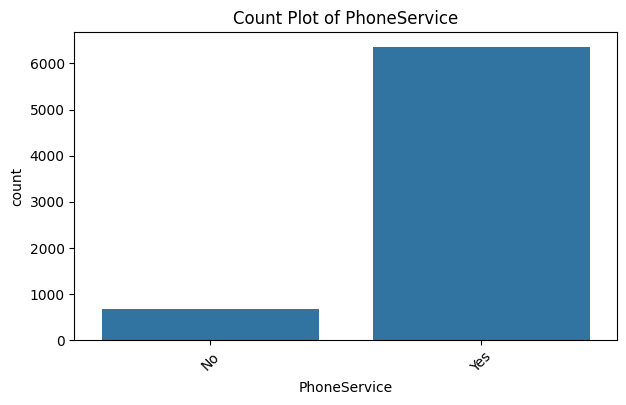

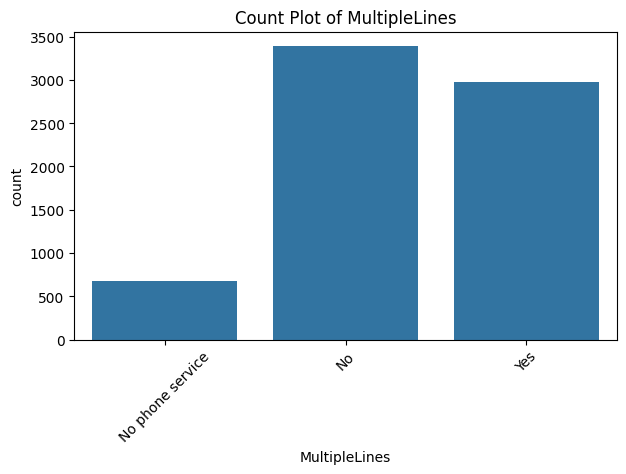

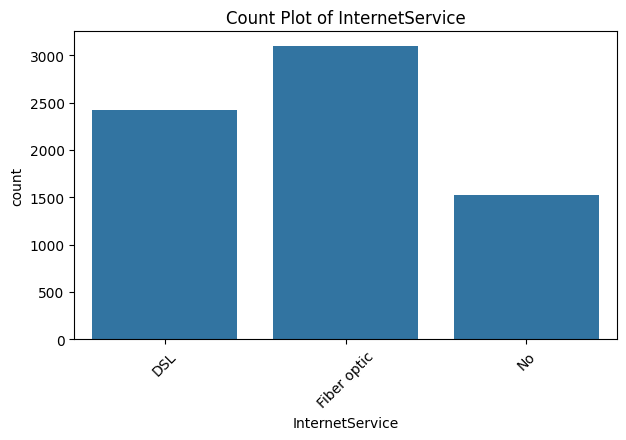

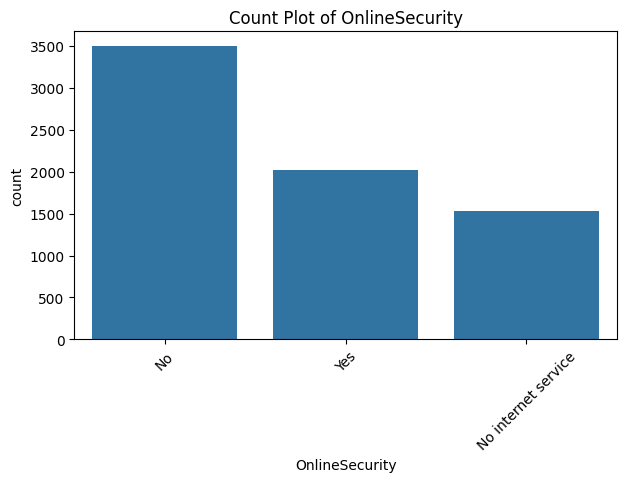

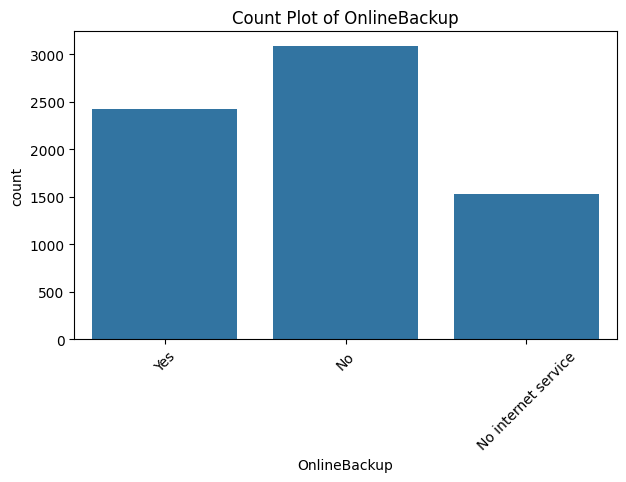

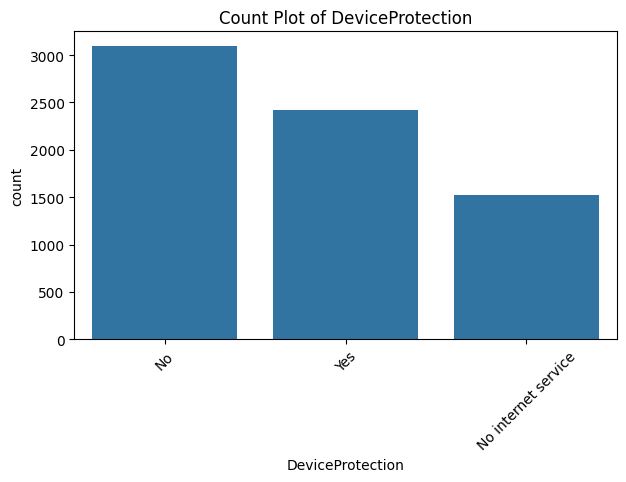

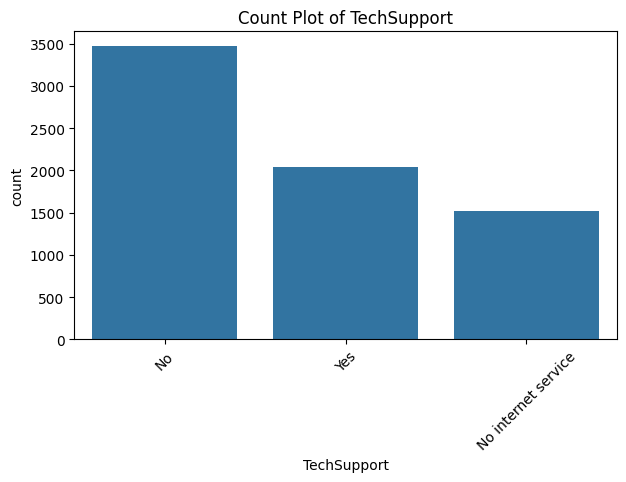

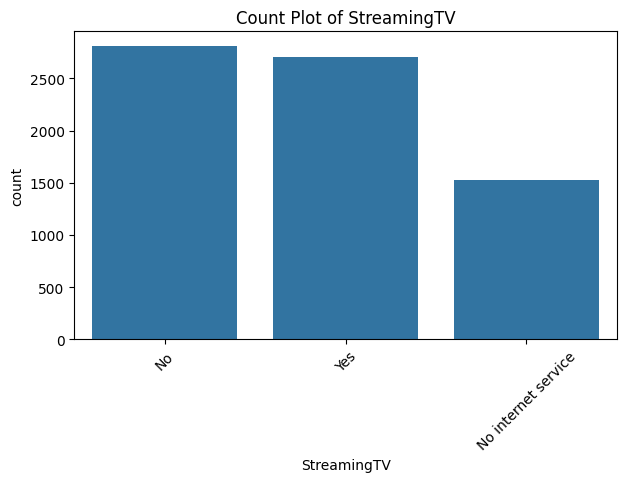

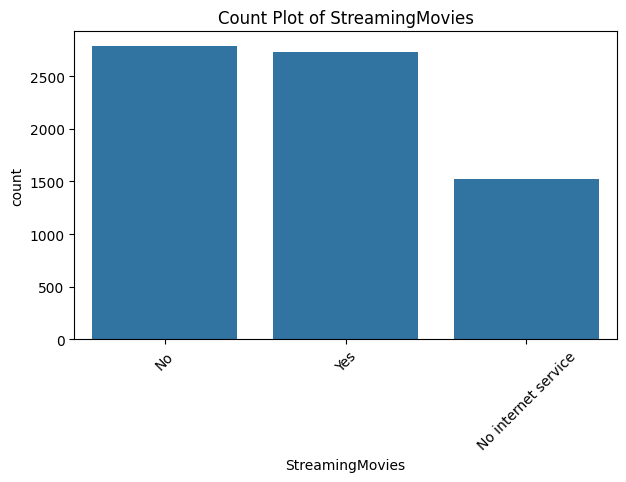

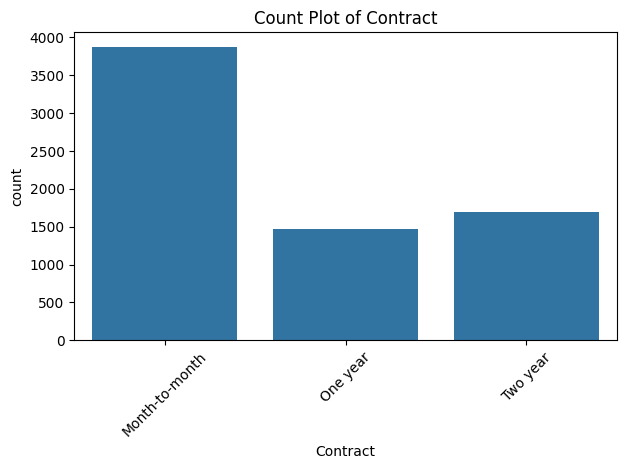

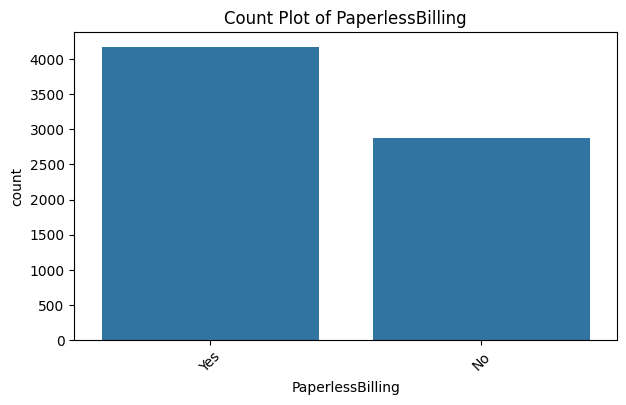

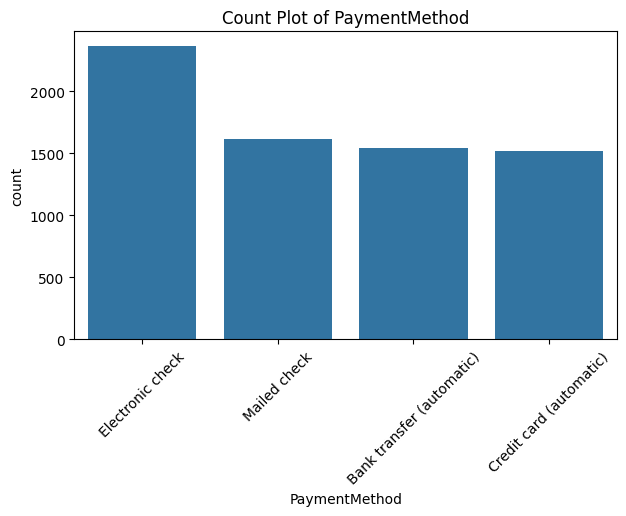

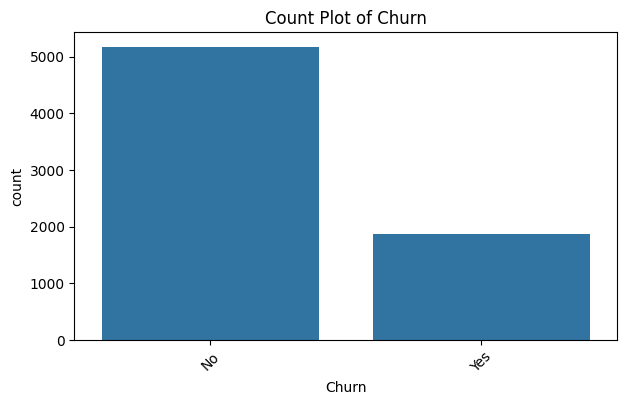

In [24]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents',
            'PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaperlessBilling','PaymentMethod','Churn']

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Count Plot of {col}')
    plt.show()

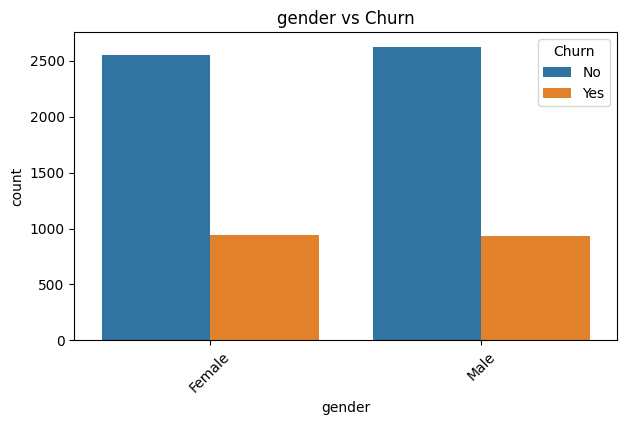

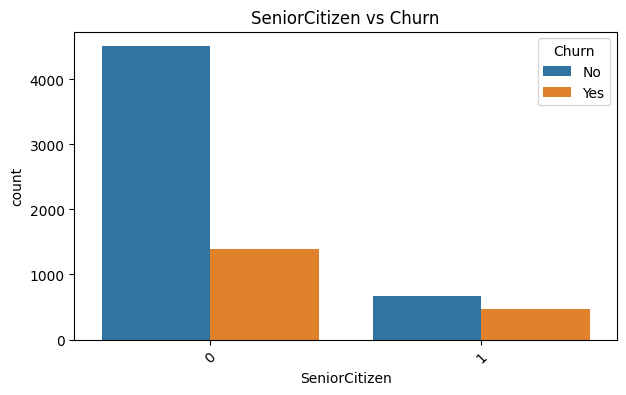

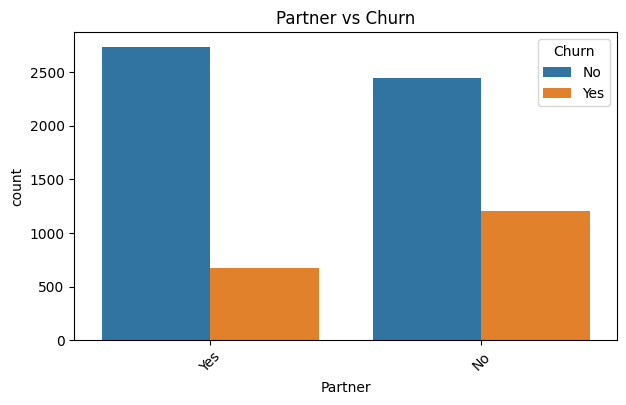

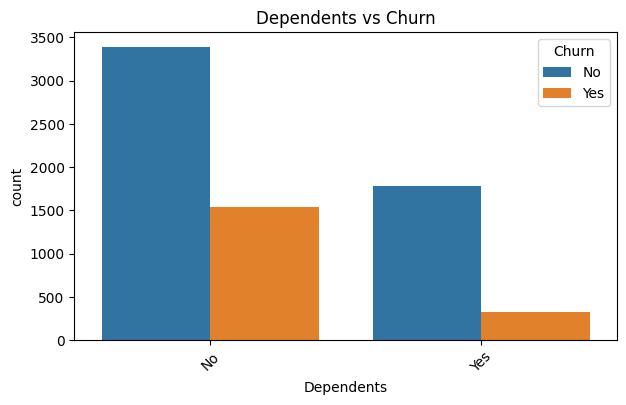

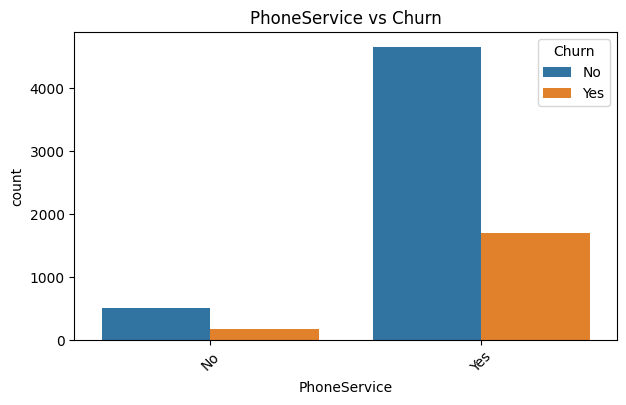

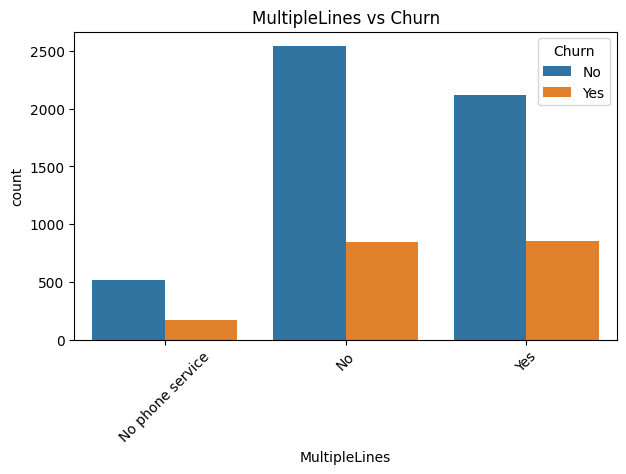

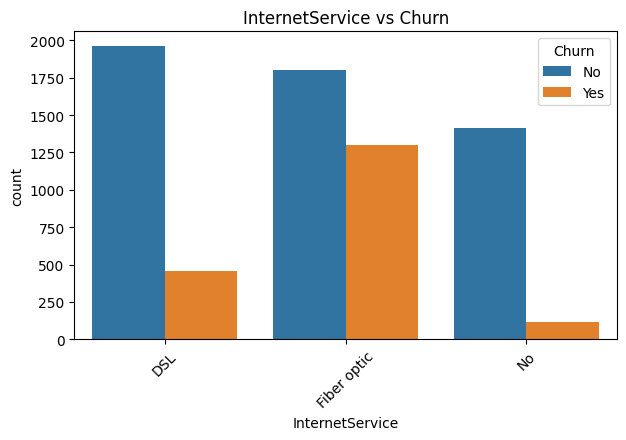

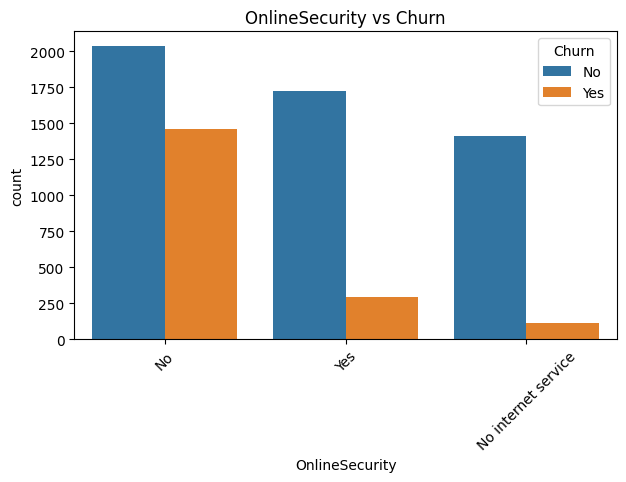

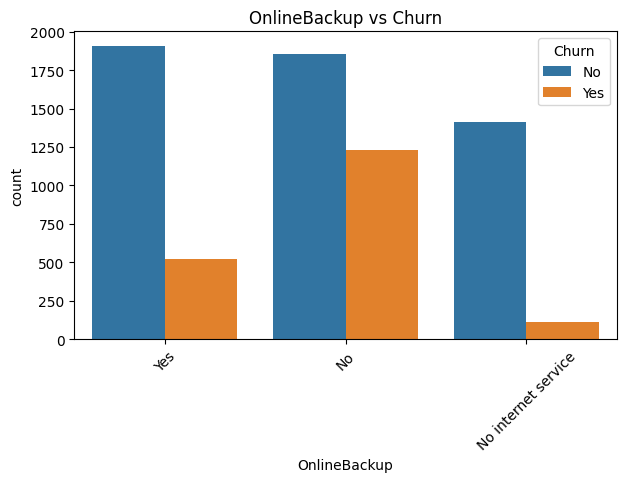

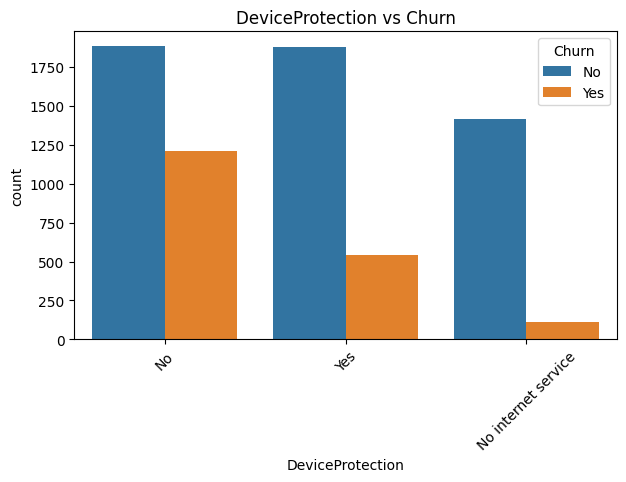

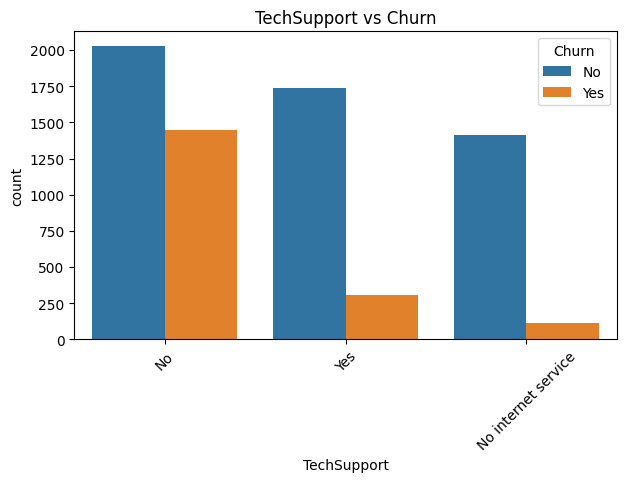

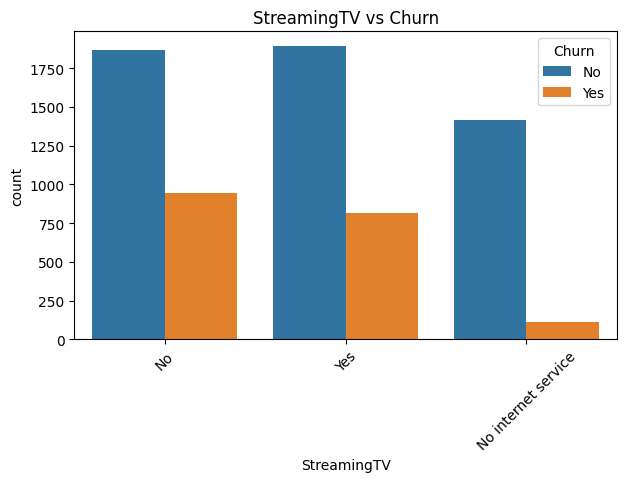

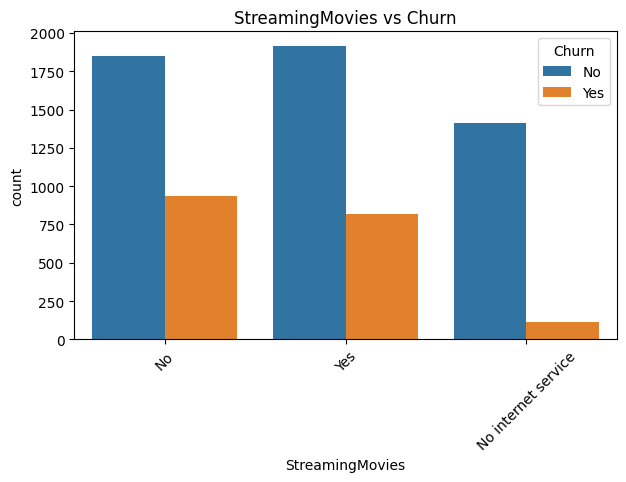

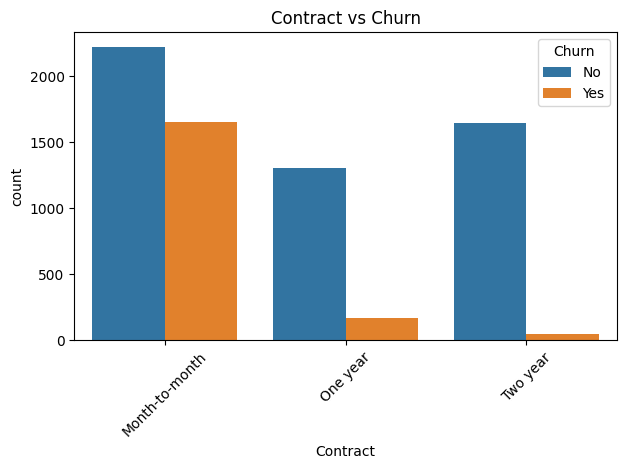

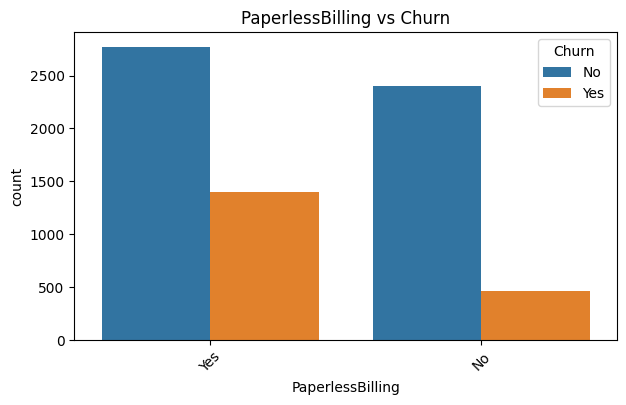

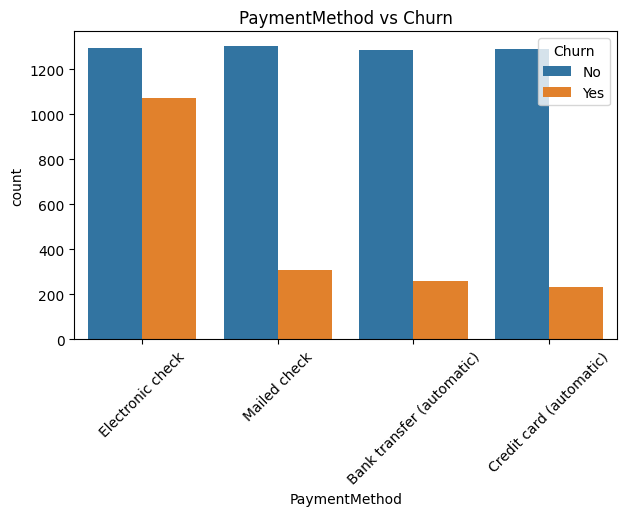

In [25]:
#category vs churn
for col in cat_cols[:-1]:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
    plt.show()

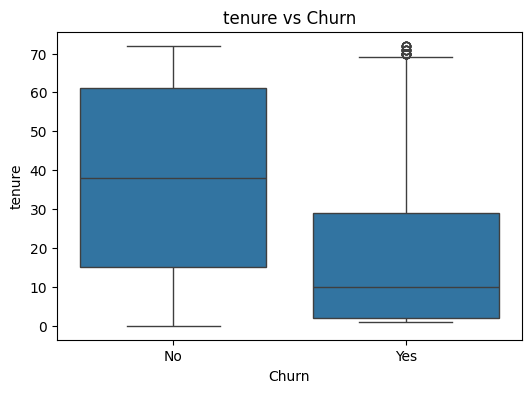

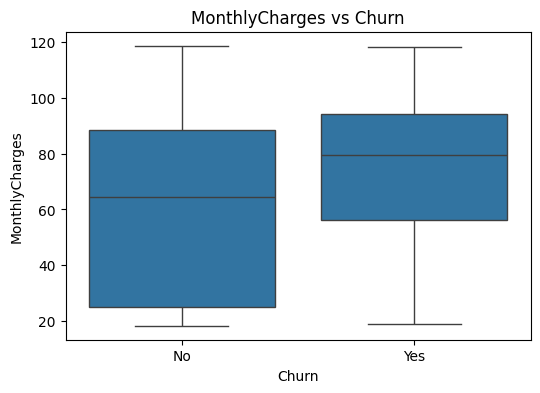

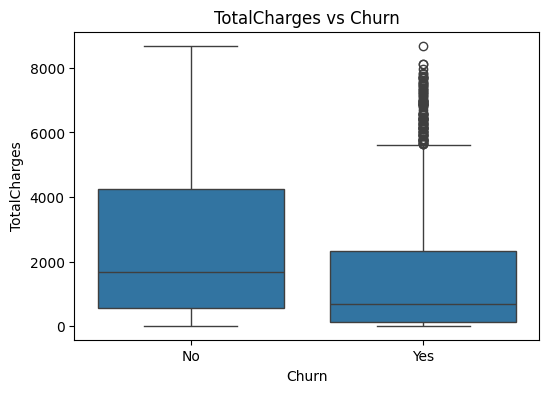

In [26]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.show()

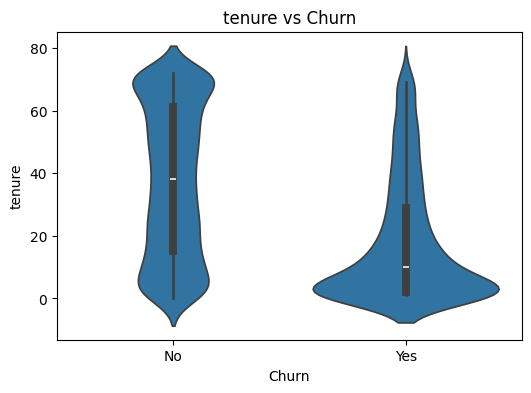

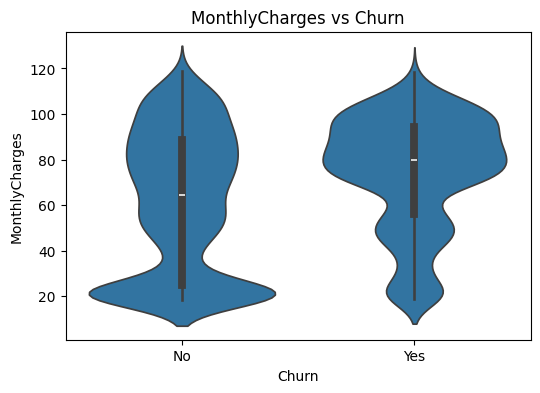

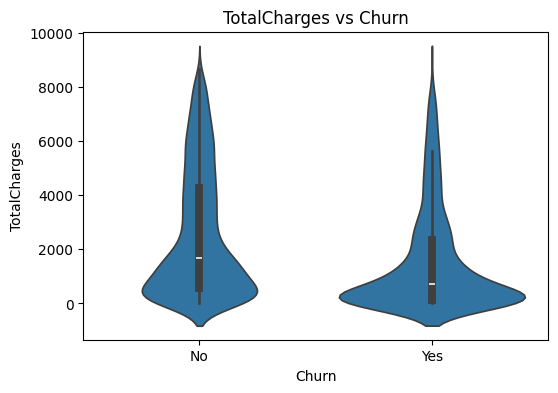

In [27]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.show()

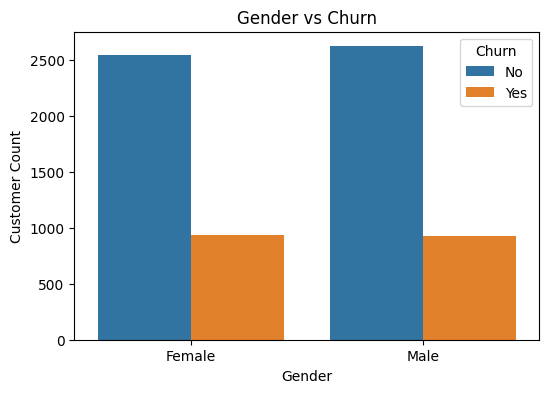

In [28]:
#Gender vs churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.show()

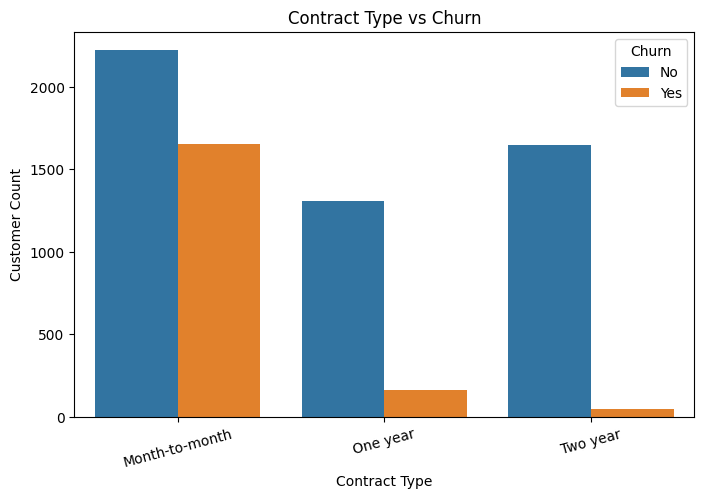

In [29]:
#Contract vs churn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=15)
plt.show()

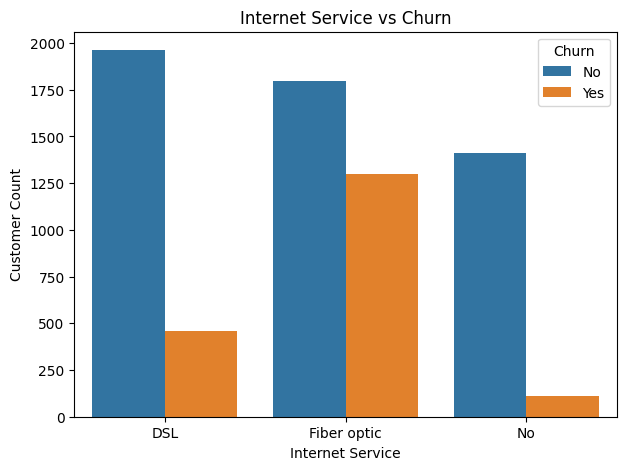

In [30]:
#internet service vs churn
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='InternetService',hue='Churn')

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.show()

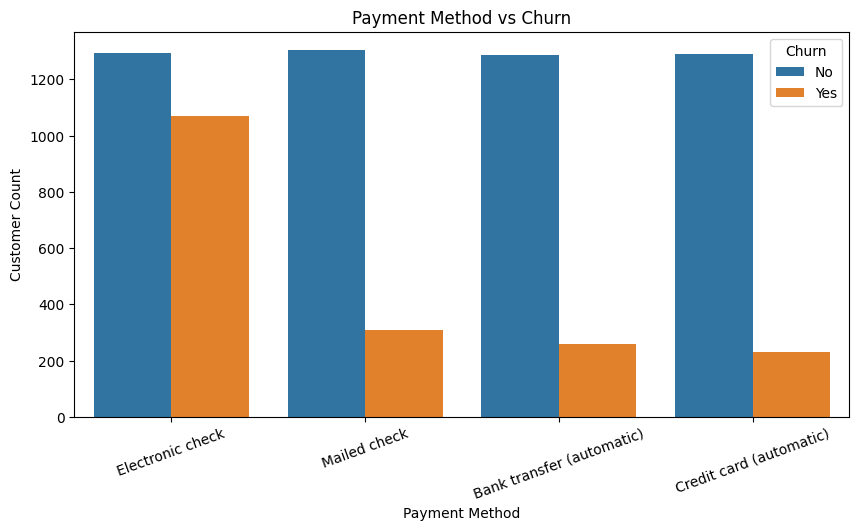

In [31]:
#payment method vs churn
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x='PaymentMethod',
              hue='Churn')

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=20)

plt.show()

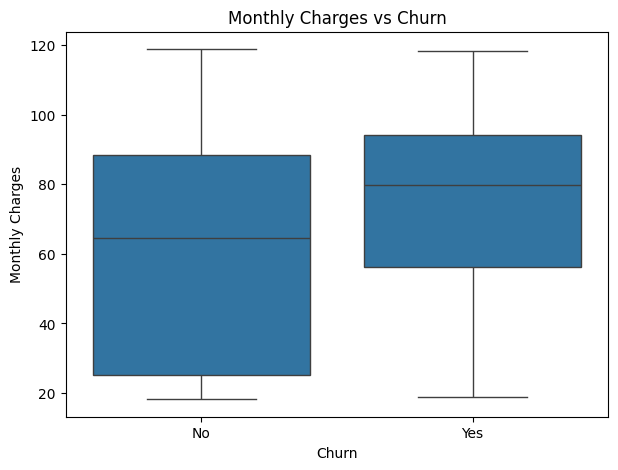

In [32]:
#monthly charges vs churn
plt.figure(figsize=(7,5))
sns.boxplot(data=df,
            x='Churn',
            y='MonthlyCharges')

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

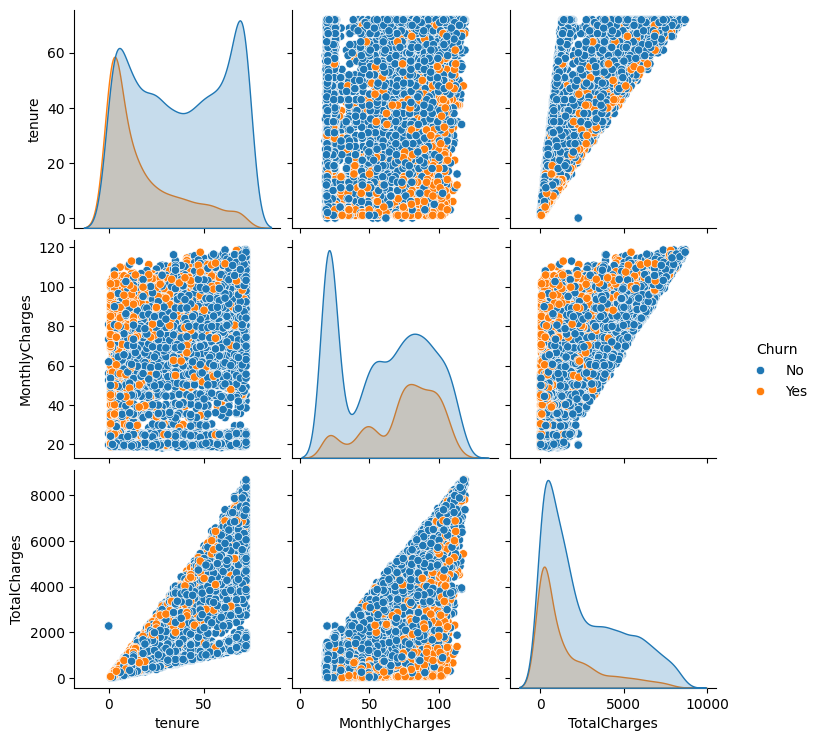

In [46]:
sns.pairplot(
    df[['tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn']],
    hue='Churn'
)

plt.show()

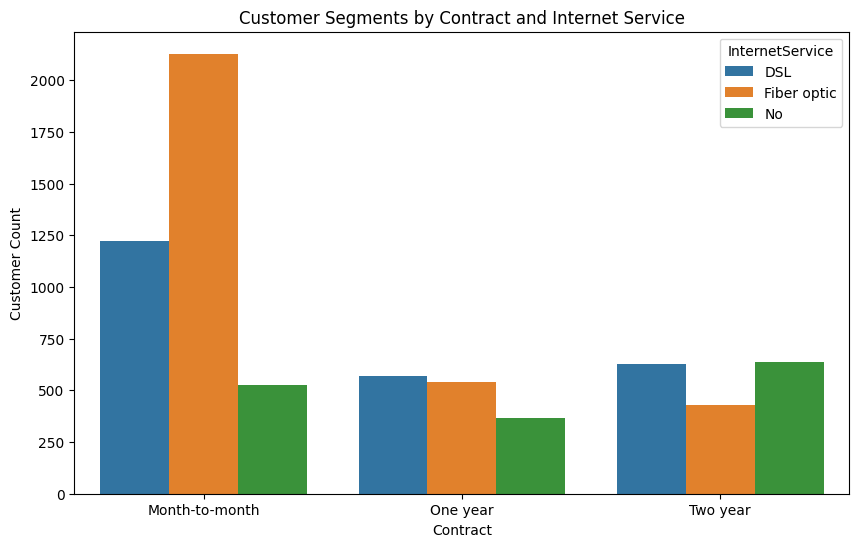

In [47]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Contract',
    hue='InternetService'
)

plt.title("Customer Segments by Contract and Internet Service")
plt.xlabel("Contract")
plt.ylabel("Customer Count")

plt.show()

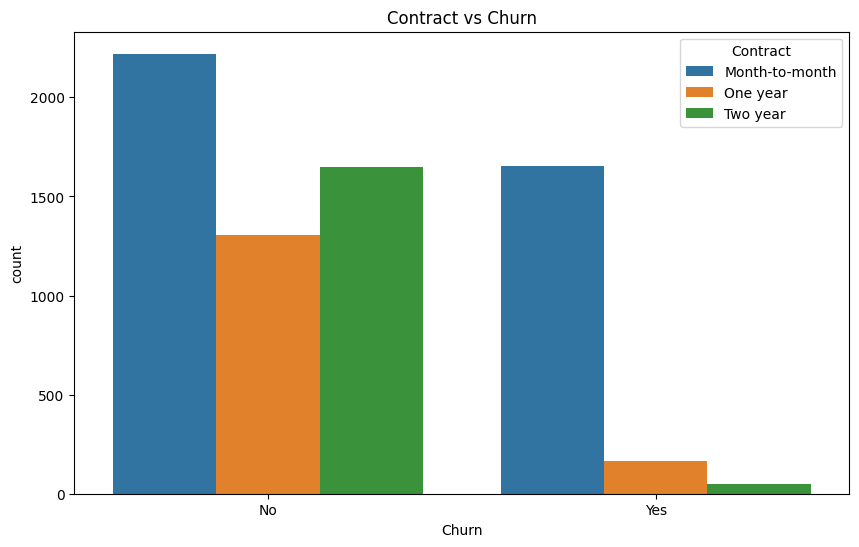

In [49]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Churn',
    hue='Contract'
)

plt.title("Contract vs Churn")
plt.show()

In [33]:
#Average Monthly charges by churn
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [34]:
#Average total by churn
df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
No,2554.765772
Yes,1531.796094


In [35]:
#Average Tenure by Churn
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


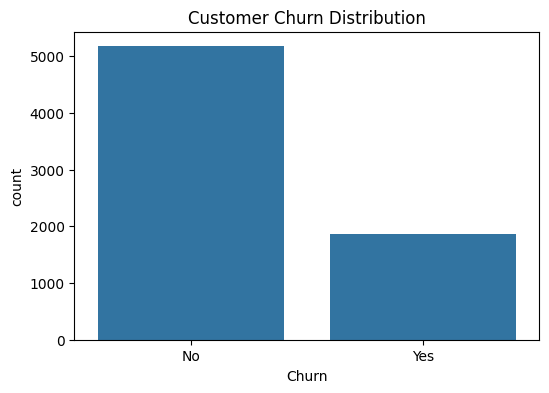

In [36]:
#what percentage of customers have churned
df['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()

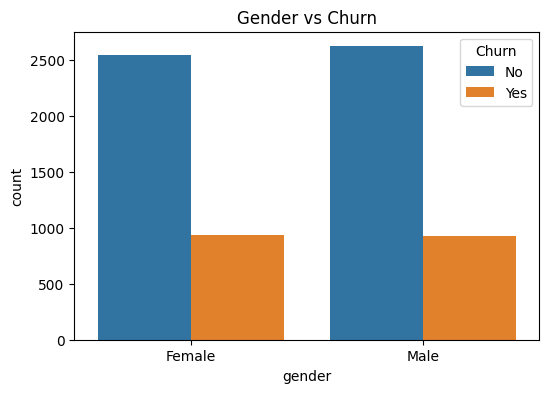

In [37]:
#Does gender affect churn
df.groupby('gender')['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='Churn')
plt.title("Gender vs Churn")
plt.show()

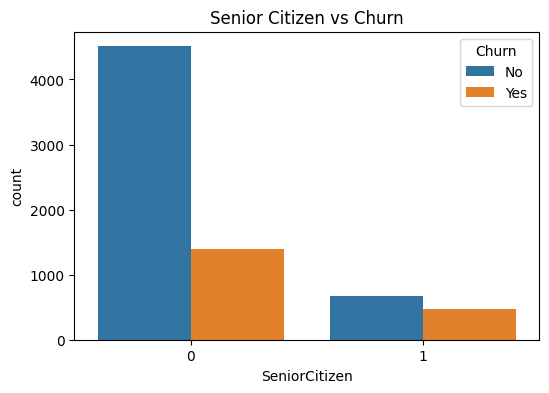

In [38]:
#Does senior citizen status affect churn?
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title("Senior Citizen vs Churn")
plt.show()

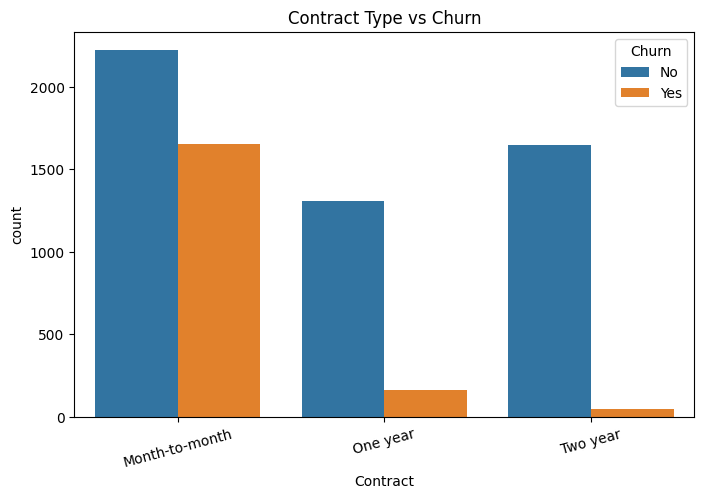

In [39]:
#Which contract type has the highest churn?
df.groupby('Contract')['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

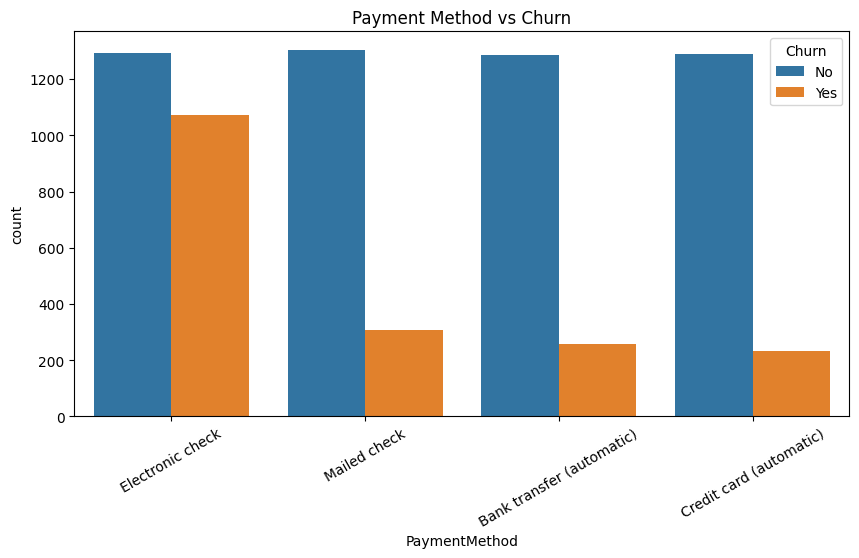

In [40]:
#Which payment method has the highest churn?
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

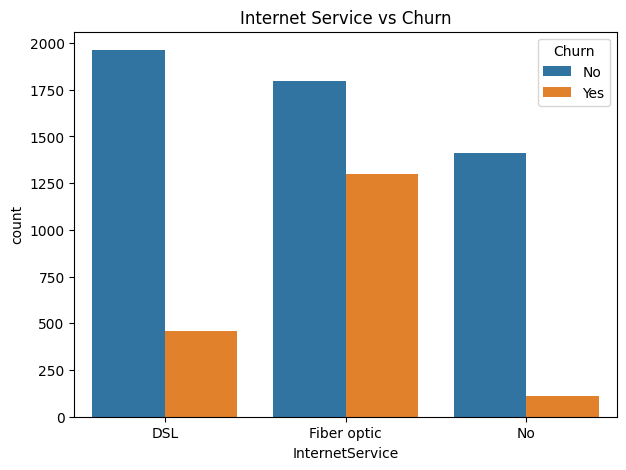

In [41]:
#Does internet service influence churn?
df.groupby('InternetService')['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Internet Service vs Churn")
plt.show()

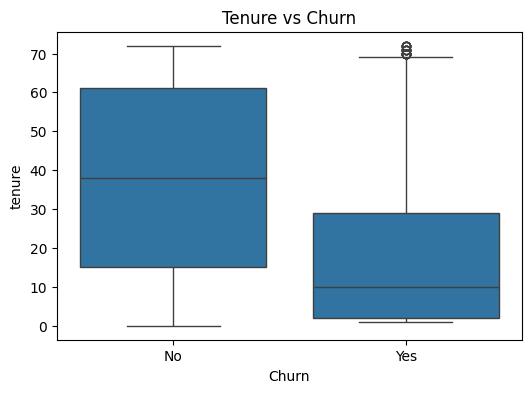

In [42]:
#Are customers with shorter tenure more likely to churn?
df.groupby('Churn')['tenure'].mean()
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()

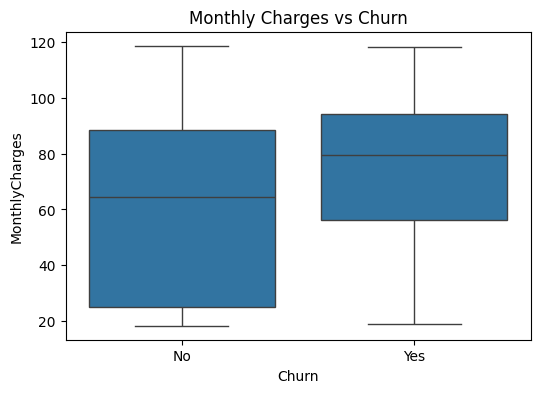

In [43]:
#Do higher monthly charges increase churn?
df.groupby('Churn')['MonthlyCharges'].mean()
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

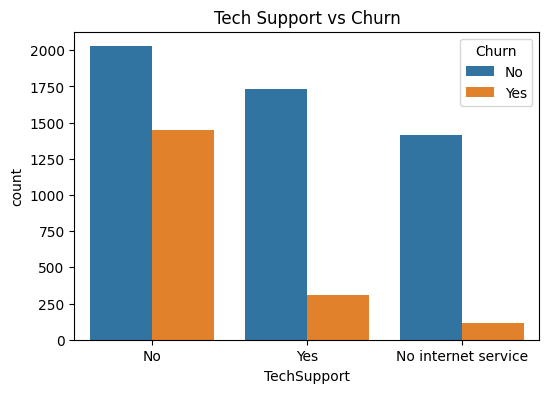

In [44]:
#Which services help retain customers?
df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title("Tech Support vs Churn")
plt.show()

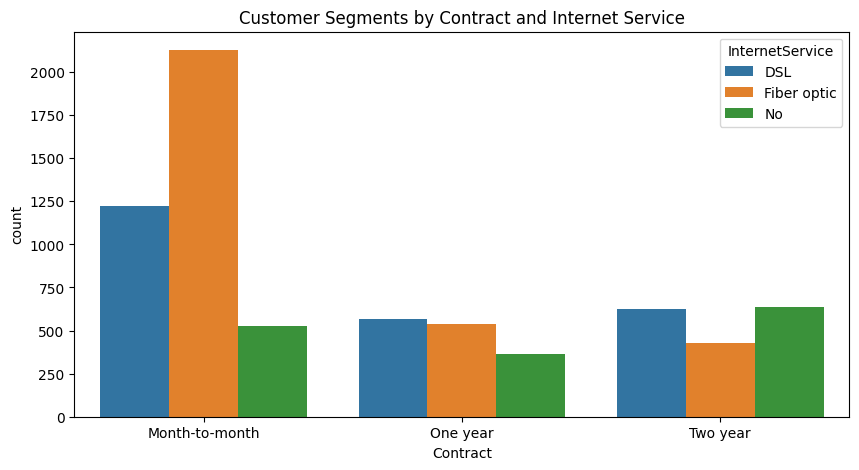

In [45]:
#Which customer segment has the highest churn risk?
df.groupby(['Contract','InternetService'])['Churn'].value_counts(normalize=True)*100

plt.figure(figsize=(10,5))
sns.countplot(data=df,
              x='Contract',
              hue='InternetService')
plt.title("Customer Segments by Contract and Internet Service")
plt.show()

Business Insights:

Month-to-month contract customers have the highest churn.

Customers with Fiber Optic internet churn more frequently.

Customers using Electronic Check have higher churn.

Customers with shorter tenure are more likely to leave.

Customers with higher monthly charges have a higher churn rate.
Customers with Tech Support and Online Security tend to stay longer.

 Conclusion

The analysis identified contract type, internet service, payment method, tenure, and monthly charges as the major factors influencing customer churn. Customers on month-to-month contracts with Fiber Optic internet and Electronic Check payments are at the highest risk of churn. The company can reduce churn by encouraging long-term contracts, improving customer support services, and offering targeted retention programs.

Conclusion:
This project analyzed customer churn using Python, SQL, and Power BI to identify the factors influencing customer attrition. The analysis revealed that customers on Month-to-Month contracts, those with Fiber Optic internet service, Electronic Check payment methods, shorter tenure, and higher monthly charges are at greater risk of churn. In contrast, customers who subscribe to value-added services such as Online Security and Tech Support are more likely to remain with the company.

The developed machine learning model demonstrated that customer churn can be predicted effectively using customer demographic, service, and billing information. These insights can help the company implement targeted retention strategies, encourage long-term contracts, improve customer support services, and offer personalized promotions to reduce churn and improve customer loyalty.